# 03 - Autoencoders

## Imports

In [1]:
import warnings
# Known benign numpy 2.x + Apple Accelerate BLAS quirk - spurious RuntimeWarnings on
# some matmuls with no actual NaN/Inf in the result.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## A Neural Network With No Labels

`02-dimensionality-reduction.ipynb` compressed features using PCA - a purely linear technique, restricted to straight-line projections. An **Autoencoder** does the same basic job (compress, then reconstruct) with a neural network instead, trained with the exact backpropagation from `deep_learning_primer/01-backpropagation-and-function-approximation.ipynb` - the only twist is that the *target* is the network's own input. No labels anywhere, which is exactly what makes this unsupervised.

## Encoder, Bottleneck, Decoder

An autoencoder has two halves sharing a narrow middle layer:
- The **Encoder** compresses the input down to the **Bottleneck** - a smaller representation than the original input.
- The **Decoder** takes that bottleneck and tries to reconstruct the *original* input from it.

Both halves train together, minimizing **Reconstruction Error** (mean squared error between input and output, the exact same loss shape used everywhere else in `deep_learning_primer`). If the network can reconstruct its input well from a much smaller bottleneck, that bottleneck must be capturing whatever's actually important about the input, since nothing else got explicitly asked for.

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def build_autoencoder(input_dim, hidden_dim, bottleneck_dim):
    return {
        'W1_enc': np.random.randn(hidden_dim, input_dim) * (1 / np.sqrt(input_dim)),
        'b1_enc': np.zeros((hidden_dim, 1)),
        'W2_enc': np.random.randn(bottleneck_dim, hidden_dim) * (1 / np.sqrt(hidden_dim)),
        'b2_enc': np.zeros((bottleneck_dim, 1)),
        'W1_dec': np.random.randn(hidden_dim, bottleneck_dim) * (1 / np.sqrt(bottleneck_dim)),
        'b1_dec': np.zeros((hidden_dim, 1)),
        'W2_dec': np.random.randn(input_dim, hidden_dim) * (1 / np.sqrt(hidden_dim)),
        'b2_dec': np.zeros((input_dim, 1)),
    }

def autoencoder_forward(X, p):
    z1_enc = p['W1_enc'] @ X + p['b1_enc']
    a1_enc = relu(z1_enc)
    bottleneck = p['W2_enc'] @ a1_enc + p['b2_enc']   # no activation - a linear bottleneck
    z1_dec = p['W1_dec'] @ bottleneck + p['b1_dec']
    a1_dec = relu(z1_dec)
    output = p['W2_dec'] @ a1_dec + p['b2_dec']
    return z1_enc, a1_enc, bottleneck, z1_dec, a1_dec, output

def train_autoencoder(X, p, learning_rate=0.05, n_epochs=5000):
    n = X.shape[1]
    loss_history = []
    for epoch in range(n_epochs):
        z1_enc, a1_enc, bottleneck, z1_dec, a1_dec, output = autoencoder_forward(X, p)
        loss = np.mean(np.sum((output - X) ** 2, axis=0))
        loss_history.append(loss)

        d_output = 2 * (output - X) / n
        d_W2_dec = d_output @ a1_dec.T
        d_b2_dec = np.sum(d_output, axis=1, keepdims=True)
        d_a1_dec = p['W2_dec'].T @ d_output
        d_z1_dec = d_a1_dec * relu_derivative(z1_dec)
        d_W1_dec = d_z1_dec @ bottleneck.T
        d_b1_dec = np.sum(d_z1_dec, axis=1, keepdims=True)
        d_bottleneck = p['W1_dec'].T @ d_z1_dec
        d_W2_enc = d_bottleneck @ a1_enc.T
        d_b2_enc = np.sum(d_bottleneck, axis=1, keepdims=True)
        d_a1_enc = p['W2_enc'].T @ d_bottleneck
        d_z1_enc = d_a1_enc * relu_derivative(z1_enc)
        d_W1_enc = d_z1_enc @ X.T
        d_b1_enc = np.sum(d_z1_enc, axis=1, keepdims=True)

        p['W2_dec'] -= learning_rate * d_W2_dec; p['b2_dec'] -= learning_rate * d_b2_dec
        p['W1_dec'] -= learning_rate * d_W1_dec; p['b1_dec'] -= learning_rate * d_b1_dec
        p['W2_enc'] -= learning_rate * d_W2_enc; p['b2_enc'] -= learning_rate * d_b2_enc
        p['W1_enc'] -= learning_rate * d_W1_enc; p['b1_enc'] -= learning_rate * d_b1_enc
    return loss_history

## Compressing Scouting Data

Same 4-feature, 3-playstyle team data as `02-dimensionality-reduction.ipynb` - climb specialists, auto specialists, generalists - compressed down to a 2-number bottleneck, same size as PCA's 2 components, for a fair comparison.

In [3]:
def make_group(climb_center, auto_center, n, rng):
    climb_rate = rng.normal(climb_center, 0.08, n)
    auto_score = rng.normal(auto_center, 0.4, n)
    endgame_reliability = climb_rate * 0.9 + rng.normal(0, 0.05, n)
    cycle_speed = auto_score * 0.7 + rng.normal(0, 0.3, n)
    return np.column_stack([climb_rate, auto_score, endgame_reliability, cycle_speed])

rng_teams = np.random.default_rng(1515)
n_per_group = 15
teams = np.vstack([
    make_group(0.85, 1.5, n_per_group, rng_teams),
    make_group(0.15, 4.5, n_per_group, rng_teams),
    make_group(0.5, 2.8, n_per_group, rng_teams),
])
true_playstyle = np.array([0] * n_per_group + [1] * n_per_group + [2] * n_per_group)
teams_scaled = (teams - teams.mean(axis=0)) / teams.std(axis=0)
X_teams = teams_scaled.T   # (4 features, N teams)

params = build_autoencoder(input_dim=4, hidden_dim=8, bottleneck_dim=2)
loss_history = train_autoencoder(X_teams, params)
print(f"Reconstruction loss: {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")

Reconstruction loss: 3.3177 -> 0.0514


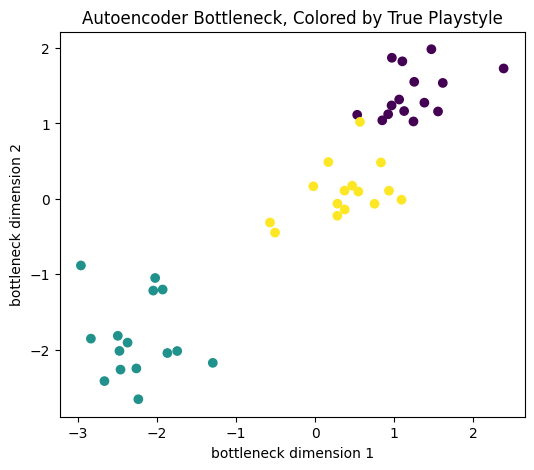

In [4]:
_, _, bottleneck, _, _, reconstructed = autoencoder_forward(X_teams, params)
bottleneck_2d = bottleneck.T

plt.figure(figsize=(6, 5))
plt.scatter(bottleneck_2d[:, 0], bottleneck_2d[:, 1], c=true_playstyle, cmap='viridis')
plt.xlabel('bottleneck dimension 1')
plt.ylabel('bottleneck dimension 2')
plt.title('Autoencoder Bottleneck, Colored by True Playstyle')
plt.show()

The three playstyles should separate about as cleanly in the autoencoder's learned 2D bottleneck as they did in PCA's 2 principal components - for data this close to genuinely linear, an autoencoder and PCA end up finding a similar compression.

## Where a Linear Method Actually Falls Short

That similarity is specific to this dataset, not a general rule - `02`'s team data happens to be close to linear (features that are mostly straight-line combinations of two underlying traits). PCA is fundamentally restricted to straight-line projections, and some real structure genuinely isn't a straight line. The clearest example: points scattered around a circle. All the real information is one number - the angle - but no single straight line through a circle can represent that angle well, since a circle spreads its variance equally in *every* direction.

In [5]:
rng_circle = np.random.default_rng(1515)
n_circle = 300
theta = rng_circle.uniform(0, 2 * np.pi, n_circle)
circle_data = np.column_stack([
    np.cos(theta) + rng_circle.normal(0, 0.05, n_circle),
    np.sin(theta) + rng_circle.normal(0, 0.05, n_circle),
])

# PCA with 1 component (from 02-dimensionality-reduction.ipynb)
mean = circle_data.mean(axis=0)
centered = circle_data - mean
eigenvalues, eigenvectors = np.linalg.eigh(np.cov(centered, rowvar=False))
order = np.argsort(eigenvalues)[::-1]
pc1 = eigenvectors[:, order][:, :1]
print(f"Eigenvalues: {eigenvalues[order].round(3)} - notice how close they are to each "
      f"other, meaning no direction is meaningfully better than any other")

reconstructed_pca = (centered @ pc1) @ pc1.T + mean
pca_error = np.mean(np.sum((circle_data - reconstructed_pca) ** 2, axis=1))
print(f"PCA (1 component) reconstruction MSE: {pca_error:.4f}")

Eigenvalues: [0.519 0.478] - notice how close they are to each other, meaning no direction is meaningfully better than any other
PCA (1 component) reconstruction MSE: 0.4769


In [6]:
circle_params = build_autoencoder(input_dim=2, hidden_dim=8, bottleneck_dim=1)
circle_loss_history = train_autoencoder(circle_data.T, circle_params, n_epochs=5000)
print(f"Autoencoder (1D bottleneck) reconstruction MSE: {circle_loss_history[-1]:.4f}")
print(f"PCA (1 component) reconstruction MSE was:        {pca_error:.4f}")

Autoencoder (1D bottleneck) reconstruction MSE: 0.0996
PCA (1 component) reconstruction MSE was:        0.4769


The autoencoder's 1-number bottleneck should reconstruct the circle several times more accurately than PCA's single best straight line - specifically *because* it can learn a nonlinear encoding (effectively, something like the angle itself) that a straight-line projection has no way to represent. This is the real, concrete justification for reaching past PCA: not every kind of structure is a straight line, and PCA has no way to bend.

## Try It Yourself

Give the circle autoencoder a bottleneck of size `2` instead of `1` and retrain. You'll likely see reconstruction error drop dramatically - close to zero. Before concluding "a bigger bottleneck captured the circle's structure better," check: is that actually what happened, or is a size-2 bottleneck (matching the original 2D input) not really *compressing* anything at all, just learning something close to the identity function? Compare this to the 1D bottleneck's error and to PCA's 1-component error above, and write one sentence on which of the three numbers actually tells you something about how well *compressed* structure was captured, versus which one is just measuring whether compression happened at all.

In [7]:
# TODO: build a circle autoencoder with bottleneck_dim=2 instead of 1, train it, and
# compare its reconstruction MSE to both the 1D-bottleneck autoencoder and PCA above


## Resources

- Hinton, G. E. & Salakhutdinov, R. R. (2006). "Reducing the Dimensionality of Data with Neural Networks." *Science*. The paper that popularized autoencoders for dimensionality reduction, including the comparison to PCA made above (paper).
- [Keras: Building Autoencoders](https://blog.keras.io/building-autoencoders-in-keras.html) - a practical walkthrough of real autoencoder variants beyond the from-scratch version built here (instructional).